In [1]:
import numpy as np
import faiss

data = np.load(f"../data/save/train_test_new-0-0-0-0.npz")

x = np.array(data["x"], dtype=np.float32)
y = np.array(data["y"], dtype=np.float32)
w = np.array(data["w"], dtype=np.float32)
coor = np.array(data["coor"], dtype=np.int64)

print(x.shape, y.shape, w.shape, coor.shape)

ModuleNotFoundError: No module named 'faiss'

In [ ]:
name_plot = "plot-b3lyp"

if name_plot == "plot-b3lyp":
    y = y[:, 0]
if name_plot == "plot-cc-b3lyp":
    y = y[:, 0] + y[:, 1] + y[:, 2] + y[:, 3]
if name_plot == "plot-cc":
    y = y[:, 1] + y[:, 2]
if name_plot == "plot-lda":
    y = y[:, 4]

# exc_over_dm_b3lyp_grids
# exc_over_dm_cc_2_grids
# exc_over_dm_cc_1_j_grids
# exc_over_dm_cc_1_k_grids

name_plot = f"{name_plot}-{x.shape[1]}"

In [ ]:
(num_sample, dim_sample) = x.shape
res = faiss.StandardGpuResources()
flat_config = faiss.GpuIndexFlatConfig()
flat_config.device = 0
index = faiss.GpuIndexFlatL2(res, dim_sample, flat_config)
index.add(x)

In [ ]:
b = x.copy()
distances, indices = index.search(b, 20)
name = data["name"]

var_y = np.var(np.einsum("ij,i->ij", y[indices], x[:, 0] * w), axis=1)
max_x_ = 1e-4
max_x = max_x_**2 * x.shape[1]

mean_of_distances = np.max(distances, axis=1)
mean_of_distances[mean_of_distances < max_x] = -1
mean_of_distances[mean_of_distances > max_x] = 0
mean_of_distances = -mean_of_distances

plot_number = 16
argsort_ = np.argsort(mean_of_distances * var_y)[::-1][:plot_number]

energy = np.einsum("ij,i->ij", y[indices[argsort_]], (x[:, 0] * w)[argsort_])
distances = distances[argsort_]
name = name[indices[argsort_]]
max_y = np.max(np.abs(energy - energy[:, [0]])) * 627.509
print(max_y)

0.13661946537718178


In [ ]:
# (sum_of_distances_reverse * var_y)[argsort_]
index_check = 0
print(
    np.sqrt(
        np.sum(
            (x[indices[argsort_]] - x[indices[argsort_]][0]) ** 2,
            axis=2,
        )
    )
    / x.shape[1])
print(distances)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.69191277e+00 1.68703699e+00 1.69720531e+00 1.68284321e+00
  1.70241368e+00 1.67944860e+00 1.67688727e+00 1.70669055e+00
  1.67515445e+00 1.67423689e+00 1.67412961e+00 1.69663823e+00
  1.69111288e+00 1.67484105e+00 1.68621910e+00 1.70870018e+00
  1.68209112e+00 1.67639291e+00 1.67880619e+00 1.70651639e+00]
 [1.51632309e+01 1.50662899e+01 1.52123728e+01 1.50736275e+01
  1.49488792e+01 1.53884869e+01 1.48793106e+01 1.54953346e+01
  1.55466375e+01 1.47443542e+01 1.55372915e+01 1.52146025e+01
  1.47483387e+01 1.47362900e+01 1.46116180e+01 1.57243595e+01
  1.46795034e+01 1.47798128e+01 1.47500992e+01 1.47375822e+01]
 [6.17804909e+00 6.15784836e+00 6.32099581e+00 6.12969971e+00
  6.0

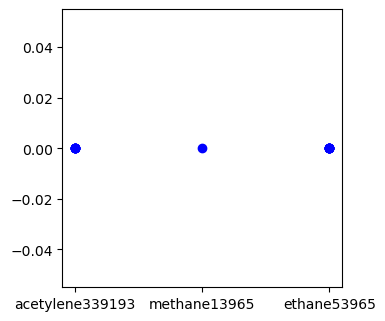

In [ ]:
from matplotlib import pyplot as plt

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72
name_energy_dict = {}

for i in range(plot_number):
    name_energy_dict[name[index_check][i]] = (
        energy[index_check][i] - energy[index_check][0]
    ) * 627.509

name_dict = {
    "methane": 0,
    "ethane": 1,
    "ethylene": 2,
    "acetylene": 3,
}

x_name_dict = {}
x_energy_dict = {}

for name_i, energy_i in name_energy_dict.items():
    x_ = (
        name_i.split("_")[0]
        + name_i.split("_")[5]
        + name_i.split("_")[6]
        + name_i.split("_")[7]
    )
    if x_ in x_name_dict:
        x_name_dict[x_].append([name_i, energy_i])
    else:
        x_name_dict[x_] = [[name_i, energy_i]]
    plt.scatter(x_, energy_i, c="b")

In [ ]:
from pathlib import Path

Path(f"{name_plot}-{max_x_}/plot/").mkdir(parents=True, exist_ok=True)

for key_, value_ in x_name_dict.items():
    for j in value_:
        plt.scatter(float(j[0].split("_")[4]), j[1], c="r")
    plt.xticks(rotation=90)
    plt.xlabel(r"$\Delta$ x ($\AA$)")
    plt.ylabel("Energy (kcal/mol)")
    plt.xlim(-0.575, 0.575)
    plt.xticks(np.arange(-0.5, 0.6, 0.1))
    plt.savefig(
        f"{name_plot}-{max_x_}/plot/{key_}_{len(value_)}.pdf", bbox_inches="tight"
    )
    plt.savefig(
        f"{name_plot}-{max_x_}/plot/{key_}_{len(value_)}.png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.close()
    print(key_, [i[0] for i in value_])

acetylene339193 ['acetylene_cc-pVDZ_0-1_1_0.5000_3_39_193', 'acetylene_cc-pVDZ_0-1_1_0.4500_3_39_193', 'acetylene_cc-pVDZ_0-1_1_0.4000_3_39_193', 'acetylene_cc-pVDZ_0-1_1_0.3500_3_39_193', 'acetylene_cc-pVDZ_0-1_1_0.3000_3_39_193', 'acetylene_cc-pVDZ_0-1_1_0.2500_3_39_193', 'acetylene_cc-pVDZ_0-1_1_0.2000_3_39_193']
methane13965 ['methane_cc-pVDZ_0-1_1_-0.3500_1_39_65']
ethane53965 ['ethane_cc-pVDZ_0-1_1_-0.1500_5_39_65', 'ethane_cc-pVDZ_0-1_1_-0.1000_5_39_65', 'ethane_cc-pVDZ_0-1_1_-0.0500_5_39_65', 'ethane_cc-pVDZ_0-1_1_-0.2000_5_39_65', 'ethane_cc-pVDZ_0-1_1_0.0000_5_39_65', 'ethane_cc-pVDZ_0-1_1_0.0500_5_39_65', 'ethane_cc-pVDZ_0-1_1_-0.2500_5_39_65', 'ethane_cc-pVDZ_0-1_1_0.1000_5_39_65']


In [ ]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72

f, axes = plt.subplots(1, 1)
axes = np.array(axes).reshape(1, 1)

begin_y = 0.125
end_y = 0.995
int_y = 0.0
begin_x = 0.175
end_x = 0.995
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-max_x * 0.1, max_x * 1.1)
        axes[i, j].set_ylim(-max_y * 1.1, max_y * 1.1)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, max_x])
            axes[i, j].set_xticklabels([0, max_x_])

for j in range(indices.shape[1]):
    print(
        distances[index_check][j],
        (energy[index_check][j] - energy[index_check][0]) * 627.509,
    )
    axes[0, 0].scatter(
        distances[index_check][j],
        (energy[index_check][j] - energy[index_check][0]) * 627.509,
        c=(color_dict[name[index_check][j].split("_")[0]],),
    )

for i, c in color_dict.items():
    axes[0, 0].scatter([-1], [-1], c=c, label=i)

plt.xlabel("Distance of cube")
plt.ylabel(r"$\Delta$ Energy (kcal/mol)")
plt.legend()

plt.savefig(f"{name_plot}-{max_x_}/sub_test.pdf", dpi=300, bbox_inches="tight")
plt.savefig(f"{name_plot}-{max_x_}/sub_test.png", dpi=300, bbox_inches="tight")
plt.clf()

9.8607613e-32 0.0
7.730837e-29 0.0
2.8729328e-28 0.0
6.110714e-28 0.0
1.04977665e-27 0.0
1.6225883e-27 0.0
2.0236254e-27 0.0
2.3814725e-27 0.0
3.1029844e-27 0.0
3.1047593e-27 0.0
3.1203393e-27 0.0
3.1247767e-27 0.0
3.144301e-27 0.0
3.1760033e-27 0.0
3.191534e-27 0.0
3.2141152e-27 0.0
3.2592774e-27 0.0
3.3141033e-27 0.0
3.3417627e-27 0.0
3.381107e-27 0.0


<Figure size 361.111x361.111 with 0 Axes>

In [ ]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([1.25, 1.25]) * 520 / 72

f, axes = plt.subplots(4, 4)
axes = axes.reshape(4, 4)

begin_y = 0.025
end_y = 0.95
int_y = 0.0
begin_x = 0.025
end_x = 0.95
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-max_x * 0.1, max_x * 1.1)
        axes[i, j].set_ylim(-max_y * 0.1, max_y * 1.1)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, max_x])
            axes[i, j].set_xticklabels([0, max_x])
        if j != 0:
            axes[i][j].set_yticks([])

for i in range(argsort_.shape[0]):
    axes_i, axes_j = np.unravel_index(i, (4, 4))
    for j in range(indices.shape[1]):
        axes[axes_i, axes_j].scatter(
            distances[i][j],
            np.abs(energy[i][j] - energy[i][0]) * 627.509,
            c=(color_dict[name[i][j].split("_")[0]],),
        )

    axes[axes_i, axes_j].text(
        0.01,
        1 - 0.01,
        f"{i}",
        transform=axes[axes_i, axes_j].transAxes,
        va="top",
    )
plt.savefig(f"{name_plot}-{max_x_}/test.pdf", dpi=300, bbox_inches="tight")
plt.savefig(f"{name_plot}-{max_x_}/test.png", dpi=300, bbox_inches="tight")
plt.clf()

<Figure size 902.778x902.778 with 0 Axes>

In [37]:
import numpy as np

val, vec = np.linalg.eigh(
    [
        [1, 0.2, 0.1],
        [0.2, 1, 0.1],
        [0.1, 0.1, -1],
    ]
)

print(vec @ np.diag(val) @ vec.T)

[[ 1.   0.2  0.1]
 [ 0.2  1.   0.1]
 [ 0.1  0.1 -1. ]]
